<a href="https://colab.research.google.com/github/Ayu-sshhhhh/Ayu-sshhhhh/blob/main/Project_1_anshu_pandey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter your name: Anshu Pandey


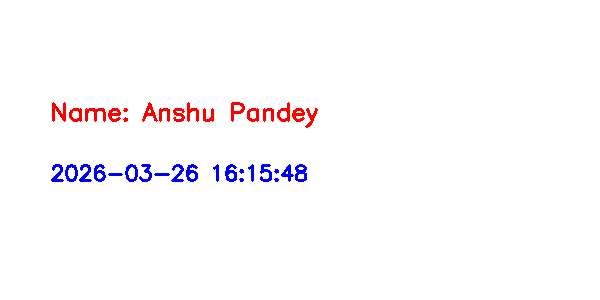

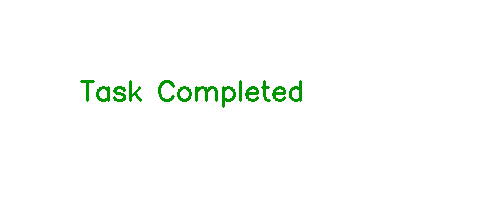

<Figure size 640x480 with 0 Axes>

In [5]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab import drive
from google.colab.patches import cv2_imshow

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Take user input & show splash screen
name = input("Enter your name: ")
img = np.ones((300, 600, 3), dtype=np.uint8) * 255
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

cv2.putText(img, f"Name: {name}", (50, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
cv2.putText(img, current_time, (50, 180), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

cv2_imshow(img) # Corrected for Colab

# 3. Folder setup
dataset_path = "/content/drive/MyDrive/DATASET"
output_base = "/content/results" # Local Colab storage for speed
healthy_path = os.path.join(output_base, "HEALTHY")
unhealthy_path = os.path.join(output_base, "UNHEALTHY")

os.makedirs(healthy_path, exist_ok=True)
os.makedirs(unhealthy_path, exist_ok=True)

# 4. Process images
if os.path.exists(dataset_path):
    for file in os.listdir(dataset_path):
        img_path = os.path.join(dataset_path, file)
        image = cv2.imread(img_path)

        if image is None: continue

        # Image Processing
        blur = cv2.GaussianBlur(image, (5, 5), 0)
        lab = cv2.cvtColor(blur, cv2.COLOR_BGR2LAB)

        # LAB thresholds for 'Red' (Adjust these based on your specific dataset)
        lower_red = np.array([20, 150, 150])
        upper_red = np.array([255, 200, 200])
        mask = cv2.inRange(lab, lower_red, upper_red)

        # Logic
        red_pixels = np.count_nonzero(mask) # Faster than np.sum
        percentage = (red_pixels / mask.size) * 100

        # Classification
        status = "unhealthy" if percentage > 5 else "healthy"
        save_dir = unhealthy_path if percentage > 5 else healthy_path

        cv2.imwrite(os.path.join(save_dir, file), image)
        print(f"Processed {file}: {status} ({percentage:.2f}%)")
else:
    print(f"Error: Path {dataset_path} not found.")

# 5. Final Message
final_img = np.ones((200, 500, 3), dtype=np.uint8) * 255
cv2.putText(final_img, "Task Completed", (80, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 150, 0), 2)
cv2_imshow(final_img)
plt.savefig("Task Completed.png")